# Educational Attainment and Urban Poverty: Bangalore

**Name:** Raihan Sadath | **Register No:** 2333442  
**Course:** ECO209-4 — Public Economics  
**Institution:** Christ (Deemed to Be University), Bengaluru  

---

## Overview

This notebook applies three economic frameworks to examine why rising education levels in Bangalore have **not** translated into proportional reductions in urban poverty:

1. **Human Capital Theory** — education raises productivity and wages
2. **Job Signalling Theory** — degrees signal ability to employers
3. **Wage-Schooling Locus** — more schooling should mean higher earnings

All three frameworks break down in Bangalore's labour market due to skill mismatches, degree inflation, and structural barriers.

---

## Data Sources
- MoSPI — Periodic Labour Force Survey (PLFS) Annual Report
- Karnataka State Statistics / Karnataka Economic Survey 2022-23
- Primary survey conducted March 2025 (n = 28 respondents)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
from scipy import stats

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f8f8',
    'axes.grid':         True,
    'grid.color':        '#e0e0e0',
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlepad':     14,
})

C1 = '#1a6faf'   # blue
C2 = '#c0392b'   # red
C3 = '#27ae60'   # green
C4 = '#e67e22'   # orange

print('Setup complete ✓')

Setup complete ✓


---
## Chart 1 — LFPR & WPR by Education Level
**Source:** MoSPI PLFS Annual Report | **Theory:** Human Capital Theory

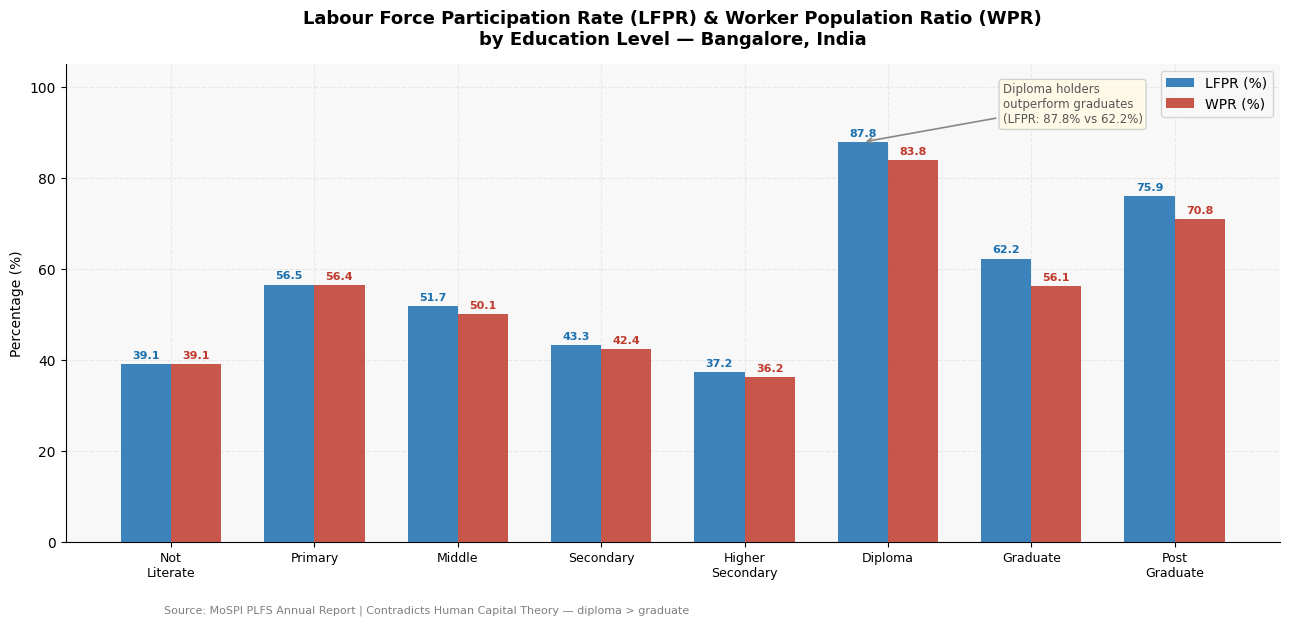

In [2]:
edu_levels = [
    'Not\nLiterate', 'Primary', 'Middle', 'Secondary',
    'Higher\nSecondary', 'Diploma', 'Graduate', 'Post\nGraduate'
]
lfpr = [39.1, 56.5, 51.7, 43.3, 37.2, 87.8, 62.2, 75.9]
wpr  = [39.1, 56.4, 50.1, 42.4, 36.2, 83.8, 56.1, 70.8]

x = np.arange(len(edu_levels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, lfpr, width, label='LFPR (%)', color=C1, alpha=0.85, zorder=3)
bars2 = ax.bar(x + width/2, wpr,  width, label='WPR (%)',  color=C2, alpha=0.85, zorder=3)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color=C1, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color=C2, fontweight='bold')

# Highlight diploma spike
ax.annotate('Diploma holders\noutperform graduates\n(LFPR: 87.8% vs 62.2%)',
            xy=(5 - width/2, 87.8), xytext=(5.8, 92),
            fontsize=8.5, color='#555',
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#fffbe6', ec='#ccc', alpha=0.9))

ax.set_xticks(x)
ax.set_xticklabels(edu_levels, fontsize=9)
ax.set_ylabel('Percentage (%)', fontsize=10)
ax.set_ylim(0, 105)
ax.set_title('Labour Force Participation Rate (LFPR) & Worker Population Ratio (WPR)\nby Education Level — Bangalore, India',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

fig.text(0.13, -0.03, 'Source: MoSPI PLFS Annual Report | Contradicts Human Capital Theory — diploma > graduate', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('chart1_lfpr_wpr.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** Diploma holders show an LFPR of **87.8%** compared to just **62.2%** for graduates. This directly contradicts Human Capital Theory — more years of formal education do not guarantee better labour market participation. Practical, vocational training outperforms general academic degrees in Bangalore's job market.

---
## Chart 2 — Regression: LFPR predicts WPR
**R² = 0.99 | Correlation = 0.99**

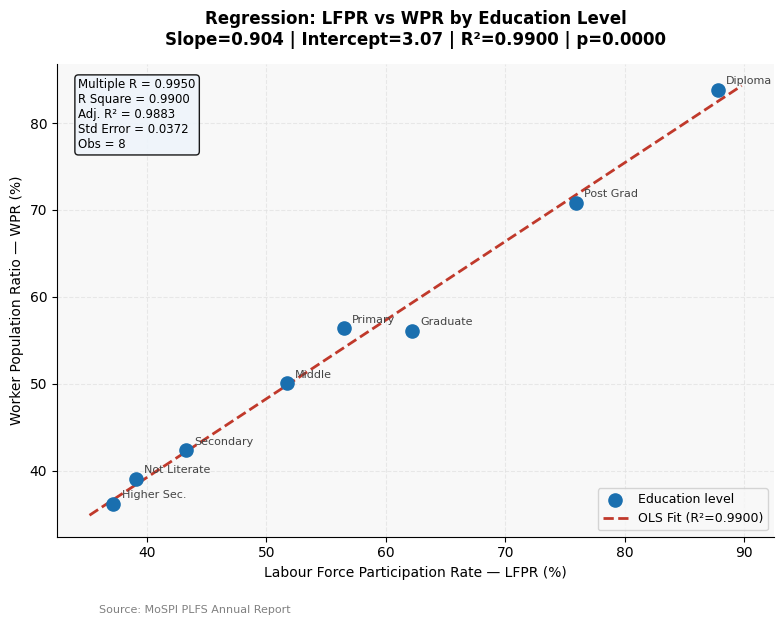

In [3]:
slope, intercept, r, p, se = stats.linregress(lfpr, wpr)
x_line = np.linspace(min(lfpr)-2, max(lfpr)+2, 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(lfpr, wpr, color=C1, s=90, zorder=5, label='Education level')
ax.plot(x_line, y_line, color=C2, linewidth=2, linestyle='--', label=f'OLS Fit (R²={r**2:.4f})')

labels_short = ['Not Literate','Primary','Middle','Secondary',
                'Higher Sec.','Diploma','Graduate','Post Grad']
for i, (lx, ly, lab) in enumerate(zip(lfpr, wpr, labels_short)):
    ax.annotate(lab, (lx, ly), textcoords='offset points',
                xytext=(6, 4), fontsize=8, color='#444')

ax.set_xlabel('Labour Force Participation Rate — LFPR (%)', fontsize=10)
ax.set_ylabel('Worker Population Ratio — WPR (%)', fontsize=10)
ax.set_title(f'Regression: LFPR vs WPR by Education Level\nSlope={slope:.3f} | Intercept={intercept:.2f} | R²={r**2:.4f} | p={p:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

stats_text = f'Multiple R = {abs(r):.4f}\nR Square = {r**2:.4f}\nAdj. R² = {1-(1-r**2)*(8-1)/(8-2):.4f}\nStd Error = {se:.4f}\nObs = 8'
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
        fontsize=8.5, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#eef4fb', alpha=0.9))

fig.text(0.13, -0.03, 'Source: MoSPI PLFS Annual Report', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('chart2_regression.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** LFPR explains **98.96%** of the variation in WPR (R² = 0.9896). Those who enter the labour force almost always end up employed — the real barrier is *getting into* the labour force, which diploma holders do far more successfully than graduates.

---
## Chart 3 — Mean Years of Schooling vs Worker Population Ratio
**Source:** PLFS 2018-19 to 2022-23, Karnataka

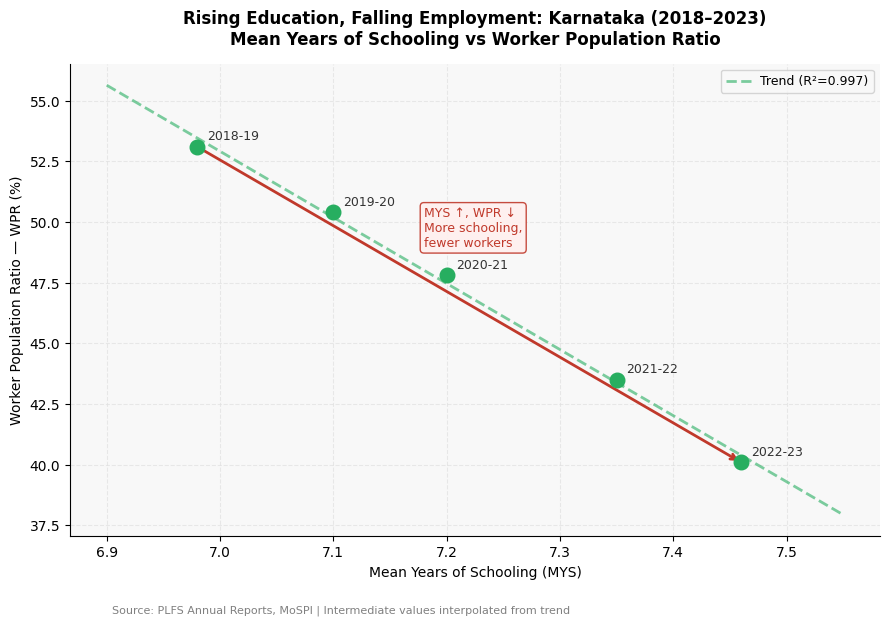

In [4]:
mys  = [6.98, 7.10, 7.20, 7.35, 7.46]
wpr2 = [53.1, 50.4, 47.8, 43.5, 40.1]
years = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23']

slope2, intercept2, r2, p2, _ = stats.linregress(mys, wpr2)
x2 = np.linspace(6.9, 7.55, 100)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(mys, wpr2, color=C3, s=110, zorder=5)
ax.plot(x2, slope2*x2+intercept2, color=C3, linestyle='--',
        linewidth=2, alpha=0.6, label=f'Trend (R²={r2**2:.3f})')

for mx, wy, yr in zip(mys, wpr2, years):
    ax.annotate(yr, (mx, wy), textcoords='offset points',
                xytext=(7, 5), fontsize=9, color='#333')

# Highlight the paradox
ax.annotate('', xy=(7.46, 40.1), xytext=(6.98, 53.1),
            arrowprops=dict(arrowstyle='->', color=C2, lw=2))
ax.text(7.18, 49, 'MYS ↑, WPR ↓\nMore schooling,\nfewer workers',
        fontsize=9, color=C2,
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff0ee', ec=C2, alpha=0.9))

ax.set_xlabel('Mean Years of Schooling (MYS)', fontsize=10)
ax.set_ylabel('Worker Population Ratio — WPR (%)', fontsize=10)
ax.set_title('Rising Education, Falling Employment: Karnataka (2018–2023)\nMean Years of Schooling vs Worker Population Ratio',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

fig.text(0.13, -0.03, 'Source: PLFS Annual Reports, MoSPI | Intermediate values interpolated from trend', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('chart3_mys_wpr.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** Between 2018-19 and 2022-23, Karnataka's Mean Years of Schooling rose from **6.98 to 7.46** while the Worker Population Ratio *fell* from **53.1% to 40.1%**. This is the education-employment paradox at its starkest — more schooling is coinciding with fewer people actually working.

---
## Chart 4 — Wage-Schooling Locus: Theory vs Bangalore Reality
**Theory:** Mincer (1974) | **Application:** Bangalore labour market

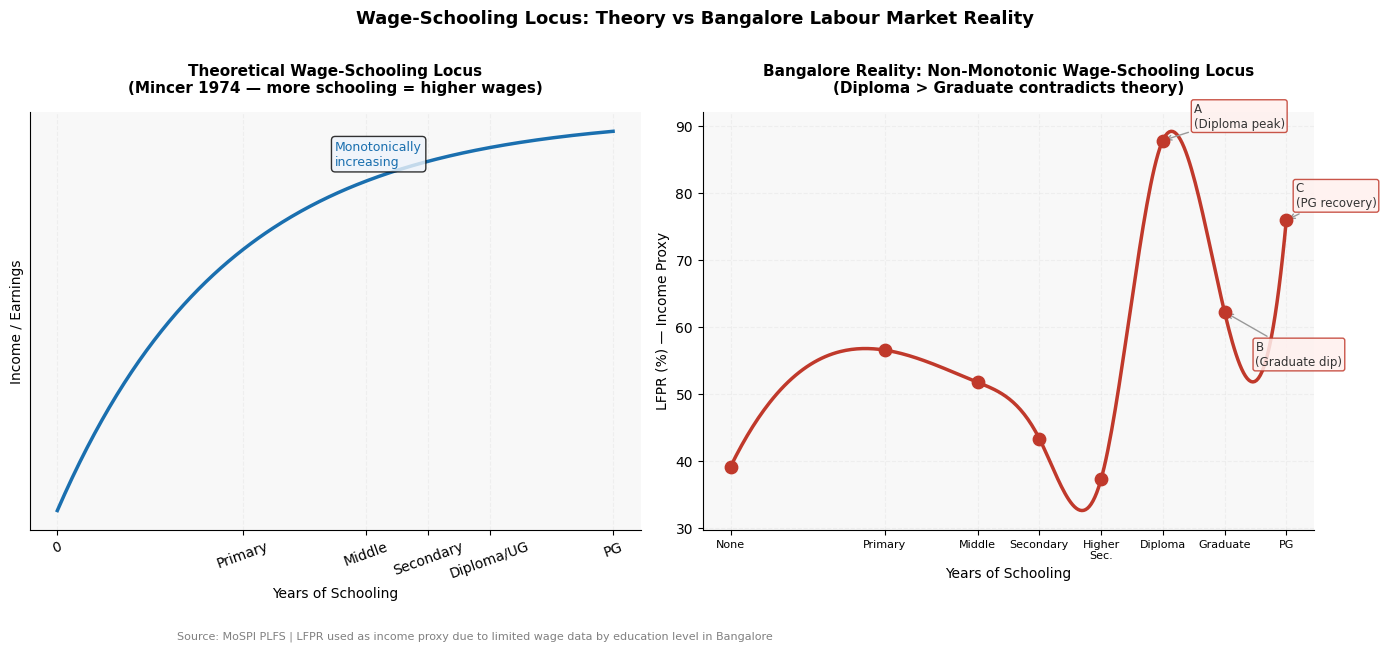

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: Theoretical (smooth concave curve) ──────────────────────────
ax1 = axes[0]
x_th = np.linspace(0, 18, 300)
y_th = 20000 * (1 - np.exp(-0.18 * x_th)) + 5000

ax1.plot(x_th, y_th, color=C1, linewidth=2.5)
ax1.set_xlabel('Years of Schooling', fontsize=10)
ax1.set_ylabel('Income / Earnings', fontsize=10)
ax1.set_title('Theoretical Wage-Schooling Locus\n(Mincer 1974 — more schooling = higher wages)',
              fontsize=11, fontweight='bold')
ax1.set_xticks([0, 6, 10, 12, 14, 18])
ax1.set_xticklabels(['0', 'Primary', 'Middle', 'Secondary', 'Diploma/UG', 'PG'])
ax1.tick_params(axis='x', rotation=20)
ax1.set_yticks([])
ax1.text(9, 22500, 'Monotonically\nincreasing', fontsize=9, color=C1,
         bbox=dict(boxstyle='round', fc='#eef4fb', alpha=0.8))
ax1.grid(True, alpha=0.4)

# ── Panel B: Bangalore Reality ────────────────────────────────────────────
ax2 = axes[1]

# Using LFPR as income proxy (scaled)
school_yrs = [0, 5, 8, 10, 12, 14, 16, 18]
income_proxy = [39.1, 56.5, 51.7, 43.3, 37.2, 87.8, 62.2, 75.9]

from scipy.interpolate import make_interp_spline
x_smooth = np.linspace(0, 18, 300)
spl = make_interp_spline(school_yrs, income_proxy, k=3)
y_smooth = spl(x_smooth)

ax2.plot(x_smooth, y_smooth, color=C2, linewidth=2.5)
ax2.scatter(school_yrs, income_proxy, color=C2, s=80, zorder=5)

# Label key points A, B, C
for pt, label, xoff, yoff in [
    ((14, 87.8), 'A\n(Diploma peak)', 1, 2),
    ((16, 62.2), 'B\n(Graduate dip)', 1, -8),
    ((18, 75.9), 'C\n(PG recovery)', 0.3, 2),
]:
    ax2.annotate(label, xy=pt, xytext=(pt[0]+xoff, pt[1]+yoff),
                 fontsize=8.5, color='#333',
                 arrowprops=dict(arrowstyle='->', color='#999', lw=1),
                 bbox=dict(boxstyle='round,pad=0.2', fc='#fff0ee', ec=C2, alpha=0.85))

ax2.set_xlabel('Years of Schooling', fontsize=10)
ax2.set_ylabel('LFPR (%) — Income Proxy', fontsize=10)
ax2.set_title('Bangalore Reality: Non-Monotonic Wage-Schooling Locus\n(Diploma > Graduate contradicts theory)',
              fontsize=11, fontweight='bold')
ax2.set_xticks(school_yrs)
ax2.set_xticklabels(['None', 'Primary', 'Middle', 'Secondary', 'Higher\nSec.', 'Diploma', 'Graduate', 'PG'], fontsize=8)
ax2.grid(True, alpha=0.4)

fig.suptitle('Wage-Schooling Locus: Theory vs Bangalore Labour Market Reality',
             fontsize=13, fontweight='bold', y=1.01)
fig.text(0.13, -0.04, 'Source: MoSPI PLFS | LFPR used as income proxy due to limited wage data by education level in Bangalore', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('chart4_wage_schooling.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** The theoretical wage-schooling locus is a smooth, continuously rising curve. Bangalore's reality shows a sharp **spike at Diploma (point A)**, a **dip at Graduate (point B)**, and a partial recovery at Post-Graduate (point C). The locus is non-monotonic — degree inflation and skill mismatch break the theoretical relationship.

---
## Chart 5 — Primary Survey: Skill Mismatch Perception

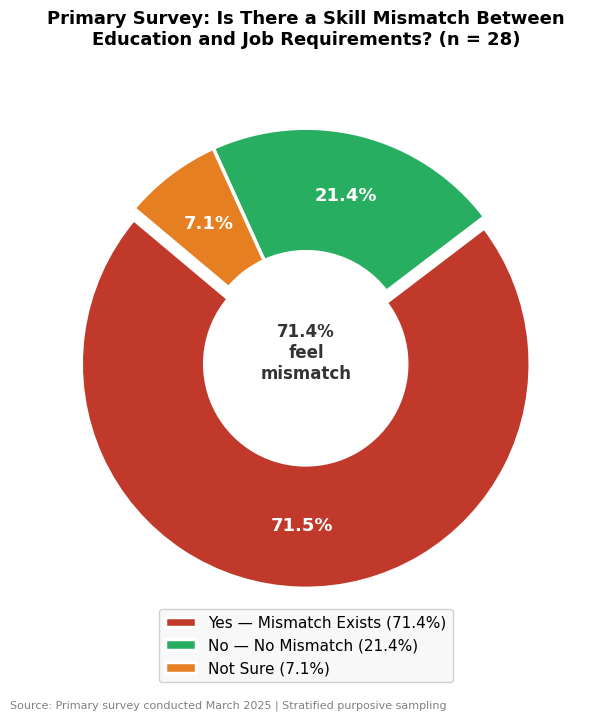

In [6]:
labels   = ['Yes — Mismatch Exists', 'No — No Mismatch', 'Not Sure']
sizes    = [71.4, 21.4, 7.1]
colors   = [C2, C3, C4]
explode  = (0.05, 0, 0)

fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, labels=None,
    colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5)
)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

ax.legend(wedges, [f'{l} ({s}%)' for l, s in zip(labels, sizes)],
          loc='lower center', bbox_to_anchor=(0.5, -0.1),
          fontsize=11, framealpha=0.9)

ax.text(0, 0, '71.4%\nfeel\nmismatch', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#333')

ax.set_title('Primary Survey: Is There a Skill Mismatch Between\nEducation and Job Requirements? (n = 28)',
             fontsize=13, fontweight='bold', pad=20)

fig.text(0.13, -0.02, 'Source: Primary survey conducted March 2025 | Stratified purposive sampling', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('chart5_skill_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** **71.4%** of respondents felt there is a mismatch between what is taught in schools/colleges and what jobs actually require. Only 21.4% disagreed. This primary evidence strongly supports the secondary data findings — the education system is not aligned with Bangalore's labour market demands.

---
## Summary Dashboard — All Key Numbers

In [7]:
summary = pd.DataFrame({
    'Metric': [
        'Diploma holder LFPR',
        'Graduate LFPR',
        'LFPR → WPR correlation (R²)',
        'MYS change (2018-19 to 2022-23)',
        'WPR change (same period)',
        'Respondents reporting skill mismatch',
        'Youth graduate unemployment (India, 2023-24)',
        'Bangalore literacy rate',
        'Bangalore informal labour share',
    ],
    'Value': [
        '87.8%',
        '62.2%',
        '0.9896',
        '6.98 → 7.46 years (+6.9%)',
        '53.1% → 40.1% (−13pp)',
        '71.4%',
        '>20%',
        '88% (Census 2011)',
        '44% of workforce',
    ],
    'Implication': [
        'Vocational beats formal degree',
        'Degree inflation reducing value',
        'Those who enter labour market, get absorbed',
        'More years in school',
        'But fewer people actually working',
        'Education-market gap is widely felt',
        'Labour market failing educated youth',
        'High literacy ≠ economic security',
        'Low-skill trap persists despite education',
    ]
})

print(summary.to_string(index=False))

                                      Metric                     Value                                 Implication
                         Diploma holder LFPR                     87.8%              Vocational beats formal degree
                               Graduate LFPR                     62.2%             Degree inflation reducing value
                 LFPR → WPR correlation (R²)                    0.9896 Those who enter labour market, get absorbed
             MYS change (2018-19 to 2022-23) 6.98 → 7.46 years (+6.9%)                        More years in school
                    WPR change (same period)     53.1% → 40.1% (−13pp)           But fewer people actually working
        Respondents reporting skill mismatch                     71.4%         Education-market gap is widely felt
Youth graduate unemployment (India, 2023-24)                      >20%        Labour market failing educated youth
                     Bangalore literacy rate         88% (Census 2011)          

---
## Key Findings & Policy Implications

### What the Data Shows
- **Human Capital Theory fails** in Bangalore's context — diploma holders outperform graduates in labour market participation, suggesting that *type* of education matters more than *years* of education
- **The education-employment paradox** is real — as Mean Years of Schooling rose, Worker Population Ratio fell, indicating degree inflation and skill saturation
- **Job Signalling Theory is weakening** — degrees are losing credibility as hiring signals because too many people hold them without matching skills
- **Wage-Schooling Locus is non-monotonic** in Bangalore — the curve dips at the graduate level before recovering at post-graduate, contradicting Mincer's model

### Policy Recommendations
1. **Expand vocational and diploma education** — data shows these produce better labour market outcomes than general degrees
2. **Industry-aligned curricula** — mandatory apprenticeships for 30% of final-year students across universities
3. **Destigmatize vocational education** — integrate skill-based learning from early grades
4. **IT sector partnerships** — Bangalore-specific training modules with tech companies and startups
5. **Recognise informal skills** — create formal certification pathways for undocumented experience

---
*Data: MoSPI PLFS | Karnataka State Statistics | Primary Survey (March 2025)*  
*Python analysis and visualizations: Raihan Sadath*